In [22]:
#!/usr/bin/env python

"""vince_eda.ipynb:Initial Exploratory Analysis for the bee project.
"""
__author__      = "Vincent Amedekah "
__copyright__   = "Copyright 2022, Bee Project"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import datetime64
import get_data as data
dataset_a, dataset_b,dataset_a_test,dataset_b_test,weather_data, bee_data, bee_full_data, air_data = data.get_data()
col_names=['year','state','colonies_inventory','unhealthy_days','very_unhealthy_days','hazardous_days','days_co','days_no2','days_ozone','days_pm2.5','days_pm10','temperature_max','temperature_min','precipitation_total']


## Aggregated USA states bee colony numbers

Text(0.5, 1.0, 'USA Annual Bee Colony Numbers')

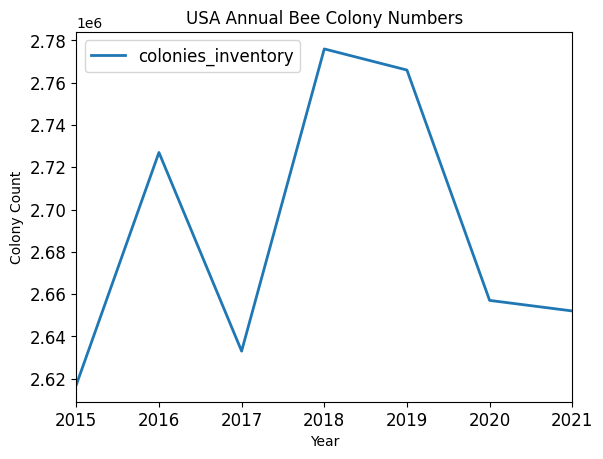

In [23]:
usa_colonies_aggregate =dataset_b[['year','colonies_inventory']].groupby('year').sum('colonies_inventory')
graph = usa_colonies_aggregate.plot(linewidth=2,fontsize=12)
graph.set_xlabel('Year')
graph.set_ylabel('Colony Count')
graph.legend(fontsize=12)
graph.set_title('USA Annual Bee Colony Numbers',fontsize=12)

## State bee colony numbers

Text(0.5, 1.0, 'Bee colony numbers by state')

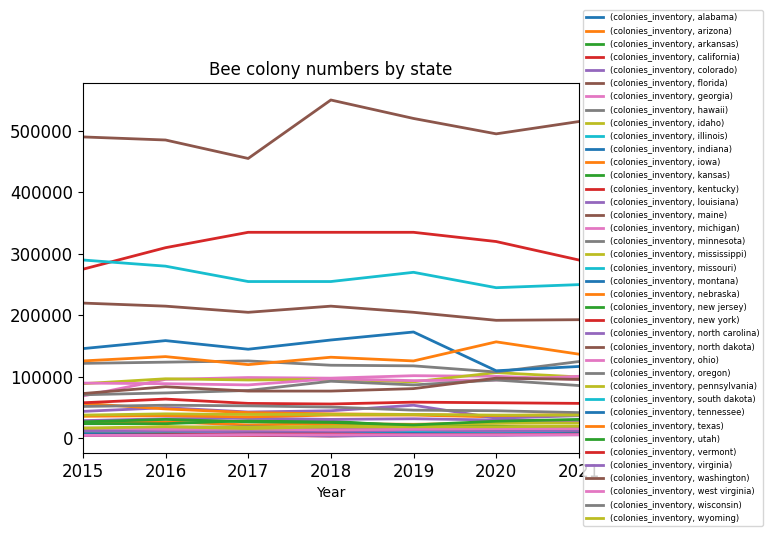

In [24]:
states_colonies_pvt = dataset_b.pivot(index=['year'],columns='state',values=['colonies_inventory'])
ax = states_colonies_pvt.plot(linewidth=2, fontsize=12)
ax.set_xlabel('Year')
ax.legend(loc='center left',bbox_to_anchor = (1,0.5), fontsize=6)
ax.set_title('Bee colony numbers by state')

## Top 5 states with higest bee colony numbers in our dataset

In [25]:
top5 = dataset_b[['state','colonies_inventory']].groupby('state').sum('colonies_inventory')['colonies_inventory'].nlargest(n=5).reset_index()
top5.head()

,state,colonies_inventory
0,north dakota,3510000
1,california,2200000
2,south dakota,1845000
3,florida,1445000
4,montana,1010000


Text(0.5, 1.0, 'Top 5 States bee colony numbers')

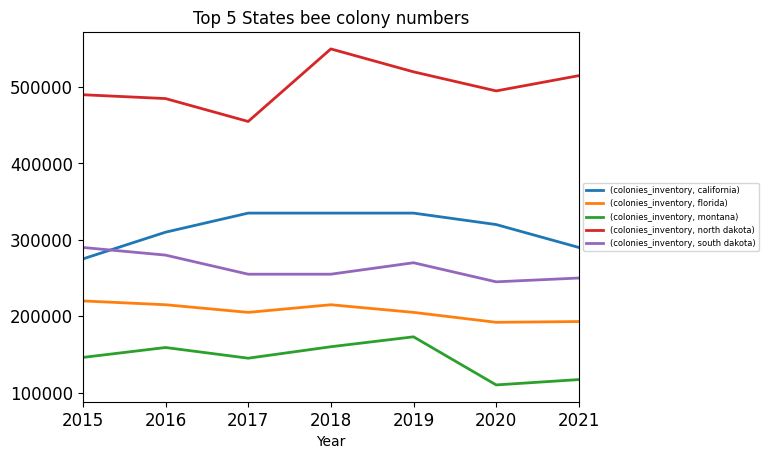

In [26]:
df_top5 = dataset_b[dataset_b['state'].isin(top5['state'])]
top5_pvt = df_top5.pivot(index=['year'],columns='state',values=['colonies_inventory'])
ax = top5_pvt.plot(linewidth=2, fontsize=12)
ax.set_xlabel('Year')
ax.legend(loc='center left',bbox_to_anchor = (1,0.5), fontsize=6)
ax.set_title('Top 5 States bee colony numbers')

### North Dakota has seen increase in bee colonies for a long time. why?

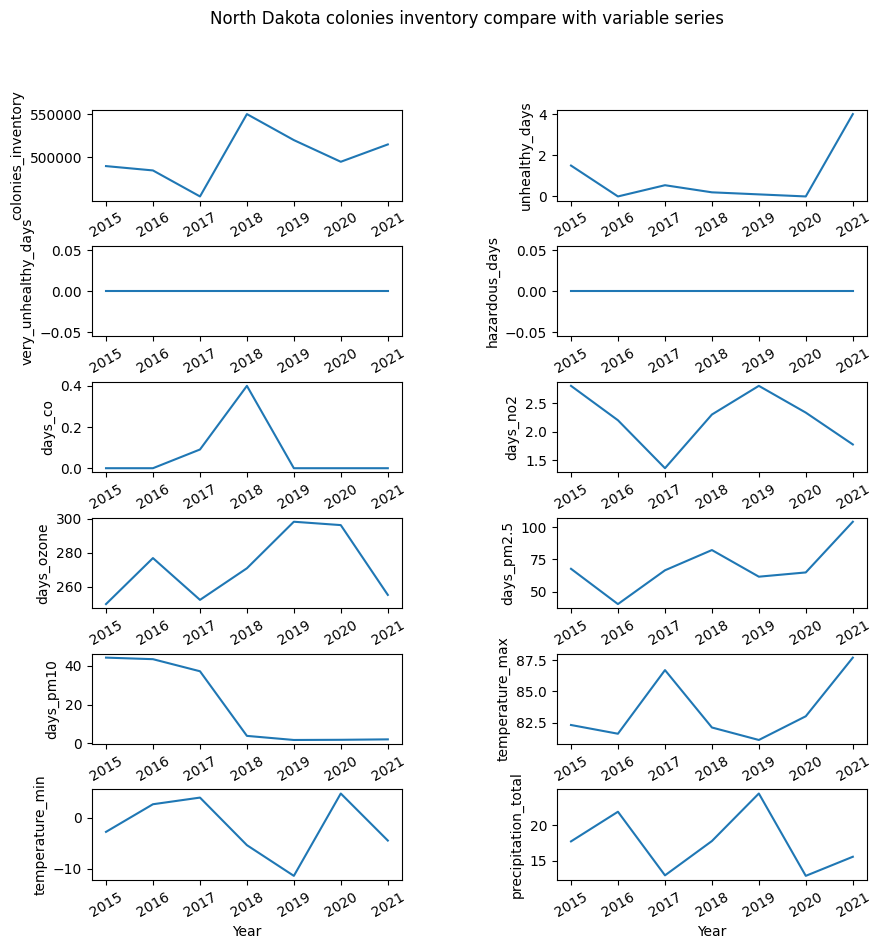

In [27]:
df = dataset_b[dataset_b['state']=='north dakota'][col_names]
fig,axs = plt.subplots(nrows=6,ncols=2)
fig.set_size_inches(10,10)
fig.subplots_adjust(wspace=0.5)
fig.subplots_adjust(hspace=0.5)
for c,ax in zip(df.columns[2:],axs.flatten()):
    ax.plot(df['year'],df[c])  
    ax.set(xlabel='Year',ylabel=c)  
    ax.tick_params(axis='x',labelrotation=30)
fig.suptitle('North Dakota colonies inventory compare with variable series')
plt.show()

North Dakota shows no harzadous day, minimal unhealthy days,days_co all remain very low. days_ozone and days_pm2.5 shows increase over time. PM2.5 are more dangerous to animal health than Pm10 which shows decreasing over the year and rose around 2012 before falling around 2018 in North Dakota.

### California has seen increase for some time and started to decrease in bee colonies. why?

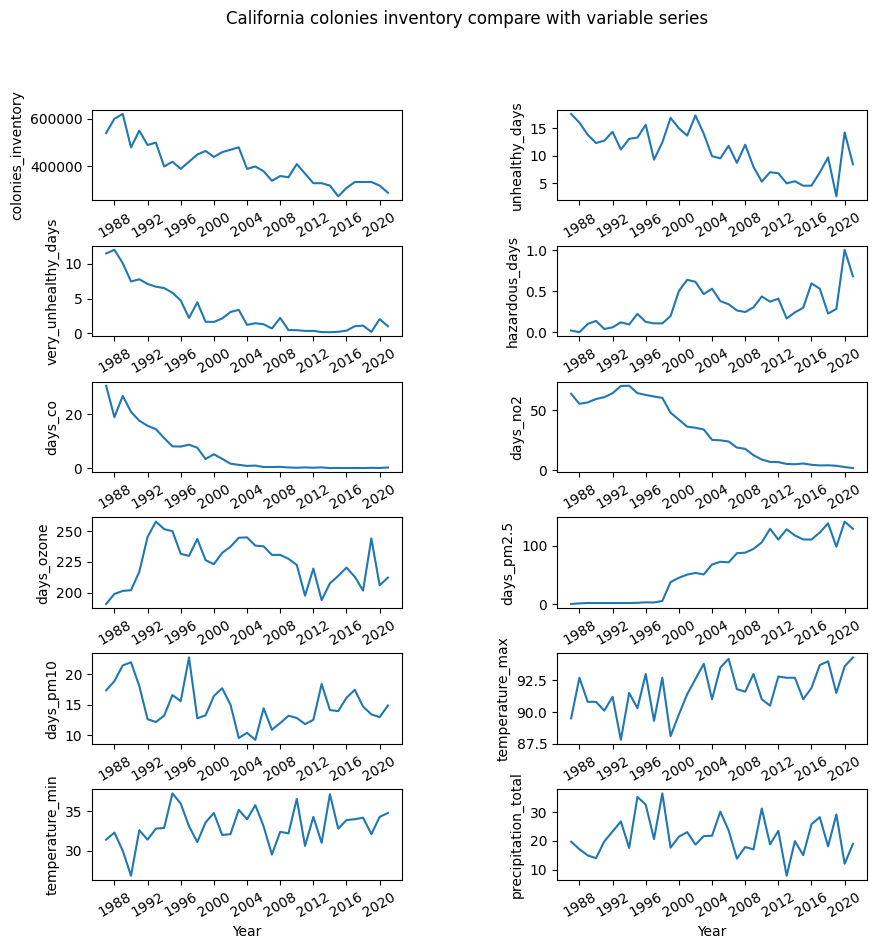

In [28]:
df = dataset_a[dataset_a['state']=='california'][col_names]
fig,axs = plt.subplots(nrows=6,ncols=2)
fig.set_size_inches(10,10)
fig.subplots_adjust(wspace=0.5)
fig.subplots_adjust(hspace=0.5)
for c,ax in zip(df.columns[2:],axs.flatten()):
    ax.plot(df['year'],df[c])  
    ax.set(xlabel='Year',ylabel=c)  
    ax.tick_params(axis='x',labelrotation=30)
fig.suptitle('California colonies inventory compare with variable series')
plt.show()

Hazardous days, pm2.5,days_Zone has been on the rise. PM10 still showed high and then decreases. Days_co and days_No2 showed decrease over the years.


## Bottom 5 states with lowest bee colony numbers in our dataset

In [29]:
bottom5 = dataset_a[['state','colonies_inventory']].groupby('state').sum('colonies_inventory')['colonies_inventory'].nsmallest(n=5).reset_index()
bottom5.head()

,state,colonies_inventory
0,kentucky,186000
1,vermont,200000
2,virginia,309000
3,tennessee,338000
4,maine,360000


Text(0.5, 1.0, 'Bottom 5 States bee colony numbers')

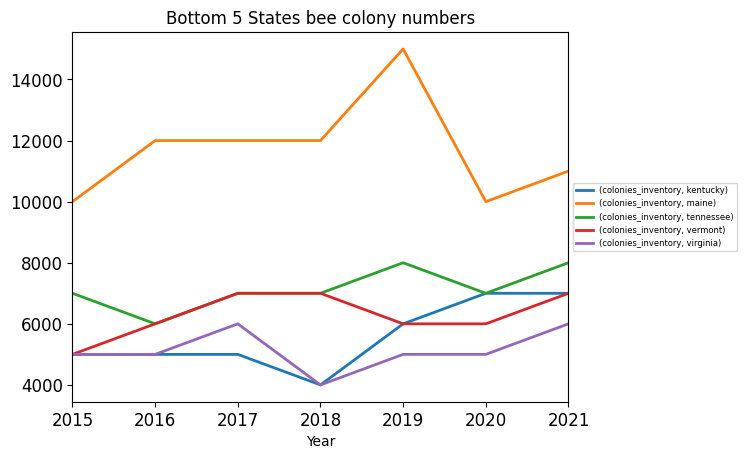

In [30]:
df_bottom5 = dataset_b[dataset_b['state'].isin(bottom5['state'])]
bottom5_pvt = df_bottom5.pivot(index=['year'],columns='state',values=['colonies_inventory'])
ax = bottom5_pvt.plot(linewidth=2, fontsize=12)
ax.set_xlabel('Year')
ax.legend(loc='center left',bbox_to_anchor = (1,0.5), fontsize=6)
ax.set_title('Bottom 5 States bee colony numbers')

### Kentucky has lowest bee colonies. why?

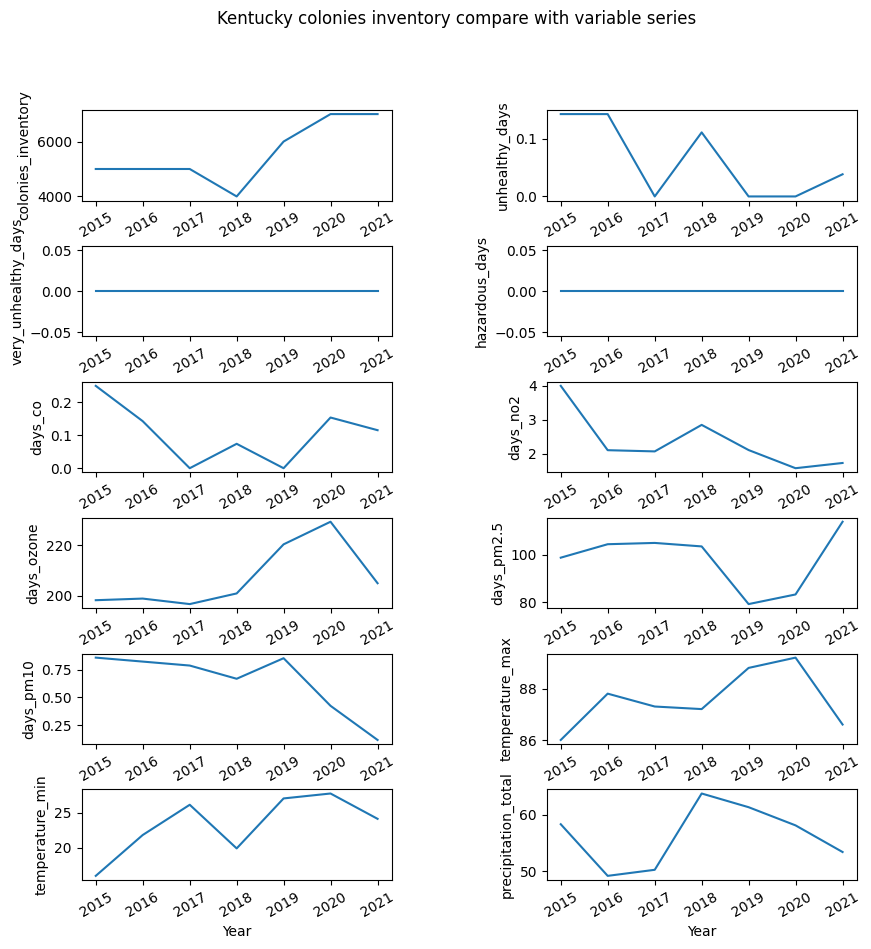

In [31]:
df = dataset_b[dataset_b['state']=='kentucky'][col_names]
fig,axs = plt.subplots(nrows=6,ncols=2)
fig.set_size_inches(10,10)
fig.subplots_adjust(wspace=0.5)
fig.subplots_adjust(hspace=0.5)
for c,ax in zip(df.columns[2:],axs.flatten()):
    ax.plot(df['year'],df[c])  
    ax.set(xlabel='Year',ylabel=c)  
    ax.tick_params(axis='x',labelrotation=30)
fig.suptitle('Kentucky colonies inventory compare with variable series')
plt.show()

Days_ozone and PM2.5 are seen on the rise in kentucky. Not that much different from other states, Could be the bee industry is just not big part of the state.

## Aggregate USA series to compare colonies_inventory with variable series

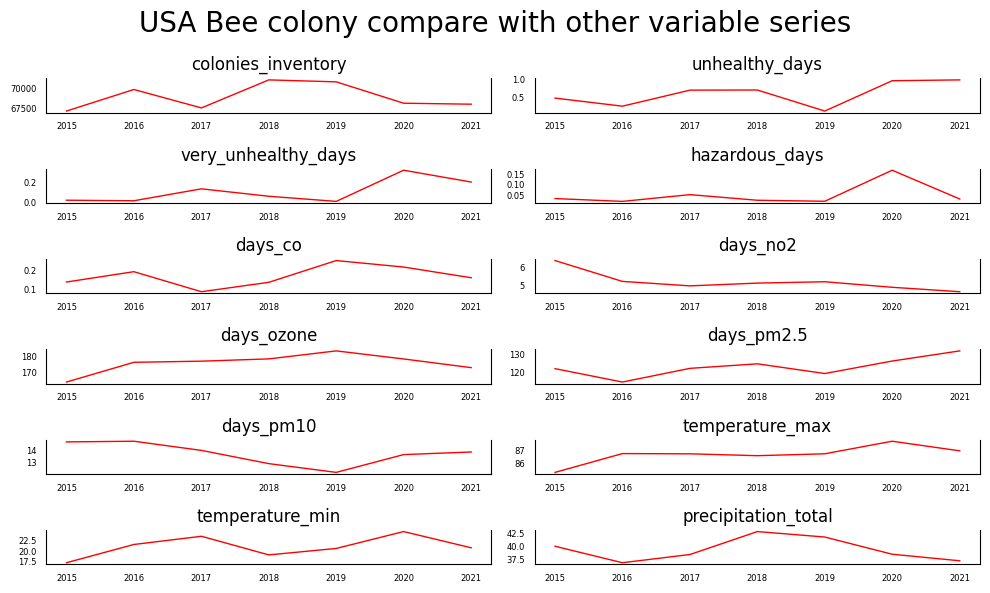

In [32]:
usa=dataset_b[[*col_names]]
usa=usa.groupby('year')[col_names[1:]].mean()

fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(10,6))
for i, ax in enumerate(axes.flatten()):
    data = usa[usa.columns[i]]
    ax.plot(data, color='red', linewidth=1)    
    ax.set_title(usa.columns[i])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)
plt.suptitle('USA Bee colony compare with other variable series', fontsize=20)
plt.tight_layout();

### Normalized view of the USA series

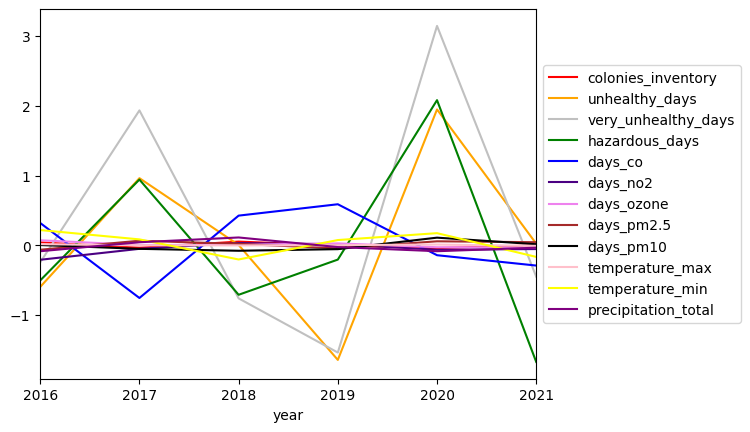

In [33]:
usa_normalized = np.log(usa).diff().dropna()
usa_normalized.plot(color=['red','orange','silver','green','blue','indigo','violet','brown','black','pink','yellow','purple']).legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


From EDA, the most important series affecting colony numbers  are days_pm2.5,hazardous_days, days_ozone but we will make a better decission after feature tests

### Granger's casuality Test
The basis behind AutoRegression is that each of the time series in the system influences each other. 
With Granger's test we can test to see which of the series has p value greater than level of 0.05 which means they do not influence the system so we can drop that series.

In [34]:
from statsmodels.tsa.stattools import grangercausalitytests
maxlag=1
test = 'ssr_chi2test'
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):    
    """Check Granger Causality of all possible combinations of the Time series.
    The rows are the response variable, columns are predictors. The values in the table 
    are the P-Values. P-Values lesser than the significance level (0.05), implies 
    the Null Hypothesis that the coefficients of the corresponding past values is 
    zero, that is, the X does not cause Y can be rejected.

    data      : pandas dataframe containing the time series variables
    variables : list containing names of the time series variables.
    """
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df
granger = grangers_causation_matrix(usa,variables=usa.columns)
granger

,colonies_inventory_x,unhealthy_days_x,very_unhealthy_days_x,hazardous_days_x,days_co_x,days_no2_x,days_ozone_x,days_pm2.5_x,days_pm10_x,temperature_max_x,temperature_min_x,precipitation_total_x
colonies_inventory_y,1.0000,0.3831,0.6334,0.3127,0.0000,0.9073,0.6875,0.2359,0.5630,0.3426,0.4009,0.0535
unhealthy_days_y,0.8267,1.0000,0.0000,0.0001,0.0417,0.0698,0.0917,0.6883,0.6050,0.0014,0.0000,0.2252
very_unhealthy_days_y,0.2383,0.0000,1.0000,0.2776,0.0000,0.3193,0.0349,0.2275,0.1206,0.0482,0.1786,0.9645
hazardous_days_y,0.1850,0.0008,0.3501,1.0000,0.0002,0.4748,0.0419,0.4235,0.0283,0.2317,0.5141,0.5679
days_co_y,0.2670,0.8087,0.7054,0.6861,1.0000,0.6537,0.8323,0.0806,0.0042,0.4838,0.1156,0.0000
days_no2_y,0.6272,0.9896,0.1286,0.0219,0.0017,1.0000,0.7505,0.9459,0.9768,0.0000,0.0852,0.4067
days_ozone_y,0.0367,0.6884,0.0541,0.0085,0.0947,0.5762,1.0000,0.9850,0.3009,0.0168,0.0117,0.0354
days_pm2.5_y,0.7680,0.5524,0.0007,0.0049,0.0790,0.0015,0.0070,1.0000,0.3886,0.0000,0.0000,0.2953
days_pm10_y,0.5546,0.2377,0.8297,0.7516,0.0064,0.1164,0.4079,0.5996,1.0000,0.6016,0.6430,0.8285
temperature_max_y,0.2171,0.0323,0.2635,0.5578,0.0003,0.6660,0.0503,0.6543,0.0100,1.0000,0.2905,0.1722


The granger test showed the series do not have granger causality with each other so Vector Auto Regression will not be suitable. This is because there is not much data to be considered over time to check the granger causality.   
The p values are over 0.05 for most series which will result in dropping all series from the data.
Dataset b can therefore not be appropriate for VAR.